In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
import tqdm
from scipy.ndimage import gaussian_filter1d
import preprocess_data as ppd
import lstm_module as lstm 
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients
import sys
import pandas as pd
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
output_dir = r"Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022"
output_dir = Path(output_dir)
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=output_dir)
session_id = 1044385384 # Arbitrary pick
session = cache.get_ecephys_session(ecephys_session_id=session_id)
behavior_id = session.behavior_session_id
behavior = cache.get_behavior_session(behavior_id)
chan = session.get_channels()

df_path = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data') / f'session_{session_id}' / f'session_{session_id}_info.csv'
df      = pd.read_csv(df_path)
# change unit_id in df to be the index
df.set_index('unit_id', inplace=True)
# map cluster_id such that 1->2, 2->3, 3->1, 4->4, 5->5 as type int
df['cluster_id'] = df['cluster_id'].map({0:0, 1:2, 2:3, 3:1, 4:4, 5:5}).astype(int)
print(df.head())

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' v

           location   probe  firing_rate  dist_from_source  cluster_id
unit_id                                                               
1049374910    VISpm  probeB     8.577549       1305.332525           2
1049374988    VISpm  probeB     0.547925       1365.633553           2
1049373561      POL  probeB    16.918544       2911.231698           0
1049373556      POL  probeB    16.652535       2911.231698           0
1049373138      PoT  probeB    19.336021       3287.960158           0


In [3]:
units = session.get_units()
channels = session.get_channels()
spike_times = session.spike_times
units = units.merge(channels, left_on='peak_channel_id', right_index=True)
units = units[(units.isi_violations < 0.5) &
                                      (units.presence_ratio > 0.9) &
                                      (units.amplitude_cutoff < 0.1) &
                                      (units.firing_rate > 0.1)]


vis_units = units[units.structure_acronym.str.startswith('VIS')]

In [4]:
bin_size = 0.004
start = int(behavior.stimulus_presentations.start_time[behavior.stimulus_presentations.active].iloc[1])
stop  = int(behavior.stimulus_presentations.end_time[behavior.stimulus_presentations.active].iloc[-1])
print(start, stop)

26 3629


In [5]:
spikes_obj = ppd.pre_process_spikes(vis_units, spike_times,bin_size=0.004, sigma=3)
spikes_obj.getSpkMat(start, stop)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 268/268 [00:20<00:00, 13.12it/s]


In [6]:
probeC = session.get_lfp(session.probes[session.probes.name == 'probeC'].index[0])
# channel ids for VISp
visp_df = chan.loc[probeC.channel][chan.loc[probeC.channel]['structure_acronym'].str.contains('VISp')]
num_channels = len(visp_df)
lfp_slice = probeC.sel(time=slice(start,stop), channel=visp_df.index)

bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
lfp_obj = ppd.pre_process_lfp(lfp_slice.values, 1250)
lfp_obj.filter_lfp(bands)

# resample data from 1250 Hz to 250 Hz to match the spike data
data = lfp_obj.lfpMat[::5,:,:]
print(data.shape)
print(spikes_obj.spkMat.shape)
# make sure the data is the same length as the spike data
if data.shape[0] > spikes_obj.spkMat.shape[0]:
    data = data[:spikes_obj.spkMat.shape[0],:,:]

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
100%|██████████| 8/8 [03:21<00:00, 25.18s/it]

(900752, 20, 9)
(900750, 268)


In [19]:
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50
num_layers = 1
seqlength = 750

In [20]:
# Preprocess data
num_trials = int(data.shape[0] / seqlength)
X = spikes_obj.spkMat[:num_trials * seqlength, :]
lfp = data[:num_trials * seqlength, :,:]

X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength, lfp.shape[1], lfp.shape[2]))

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])

y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], y_train.shape[2], y_train.shape[3])
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], y_test.shape[2], y_test.shape[3]) 

X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

# remove non-tensor variables to free up memory
del X, lfp, X_reshaped, lfp_reshaped, X_train, X_test, y_train, y_test

print(X_trainT.shape, y_trainT.shape)
print(X_testT.shape, y_testT.shape)

torch.Size([720000, 268]) torch.Size([720000, 20, 9])
torch.Size([180750, 268]) torch.Size([180750, 20, 9])


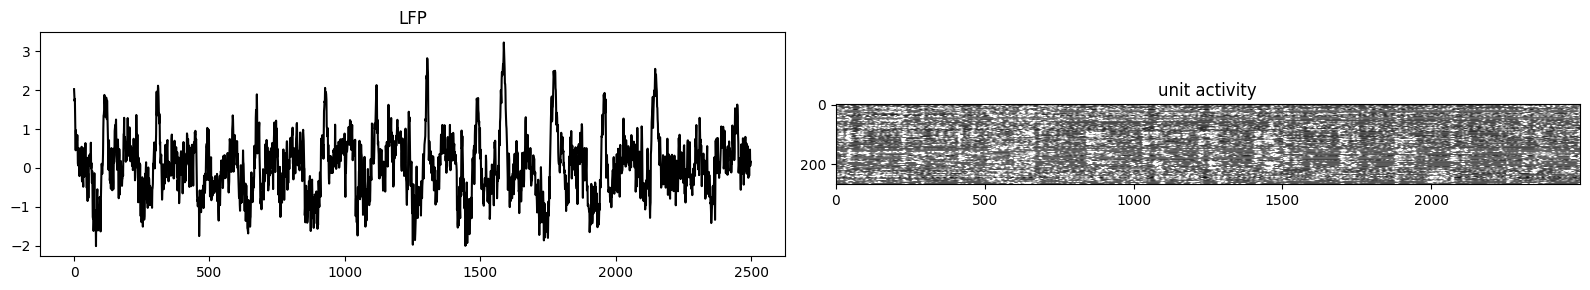

In [9]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_trainT.numpy()[:int(10/bin_size),10,0],'k',label='LFP')
# ax[0].plot(stats.zscore(np.mean(X_trainT.cpu().detach().numpy()[:int(10/bin_size),:], axis=1)),'r',label='unit activity')
ax[0].set_title('LFP')

ax[1].imshow(X_trainT.numpy()[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

In [23]:
# for channel 5, train a model with decreasing number of units chosen randomly
num_cells = np.arange(10, 201, 20)
num_epochs = 15
num_runs = 10
r2 = np.zeros((len(num_cells), 2, num_runs))
criterion = torch.nn.MSELoss()


for i, n in enumerate(num_cells):
    print(f'Fitting model with {n} units')
    for j in range(num_runs):
        model = lstm.process_model(lstm.LSTMnet(n, hidden_size, num_layers), seqlength, criterion, device)
        random_units = np.random.choice(input_size, n, replace=False)
        losses = model.train(X_trainT[:,random_units], y_trainT[:,5, 0].unsqueeze(1) , num_epochs)

        yHat_test  = model.evaluate(X_testT[:,random_units])
        yHat_train = model.evaluate(X_trainT[:,random_units])
        
        r2[i,0, j] = r2_score(y_testT[:,5, 0].cpu().detach().numpy(), yHat_test)
        r2[i,1, j] = r2_score(y_trainT[:,5, 0].cpu().detach().numpy(), yHat_train)

Fitting model with 10 units
Fitting model with 30 units
Fitting model with 50 units
Fitting model with 70 units
Fitting model with 90 units
Fitting model with 110 units
Fitting model with 130 units
Fitting model with 150 units
Fitting model with 170 units
Fitting model with 190 units


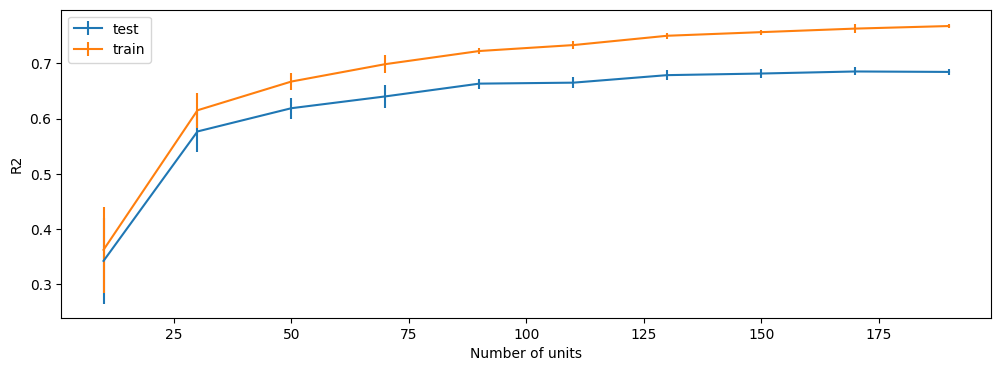

In [24]:
# plot the results
fig, ax = plt.subplots(1,1,figsize=(12, 4))
ax.errorbar(num_cells, np.mean(r2[:,0,:], axis=1), np.std(r2[:,0,:], axis=1), label='test')
ax.errorbar(num_cells, np.mean(r2[:,1,:], axis=1), np.std(r2[:,1,:], axis=1), label='train')
ax.set_xlabel('Number of units')
ax.set_ylabel('R2')
ax.legend()
plt.show()


In [22]:
criterion = torch.nn.MSELoss()
num_epochs = 15
lossesAll = np.zeros((y_trainT.shape[1], num_epochs, len(bands)+1))

# initialize dictionary to store trained models 
models = {}

for chani in range(num_channels):
    sys.stdout.write('\r' + 'Training model for channel ' + str(chani + 1) + ' out of ' + str(num_channels))
    for bandi in range(len(bands)+1):
        model = lstm.process_model(lstm.LSTMnet(input_size, hidden_size, num_layers), seqlength, criterion, device)
        models[chani, bandi] = model
        losses = model.train(X_trainT, y_trainT[:,chani, bandi].unsqueeze(1) , num_epochs)
        lossesAll[chani,:, bandi] = losses

Training model for channel 20 out of 20

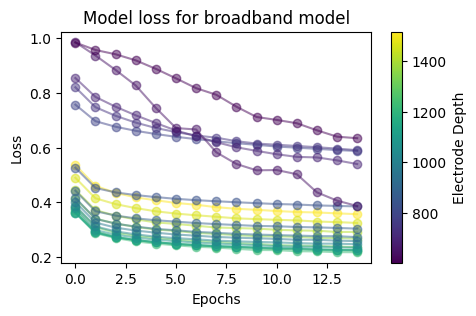

In [23]:
# plot losses for the broadband model for all channels color coded by depth
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig,ax = plt.subplots(1,1,figsize=(5,3))

norm = mcolors.Normalize(vmin=visp_df['dorsal_ventral_ccf_coordinate'].min(), vmax=visp_df['dorsal_ventral_ccf_coordinate'].max())
cmap = cm.viridis

for chani in range(num_channels):
    color = cmap(norm(visp_df['dorsal_ventral_ccf_coordinate'].iloc[chani]))
    ax.plot(lossesAll[chani, :, 0], 'o-', alpha=0.5, color=color)

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss for broadband model')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Electrode Depth')

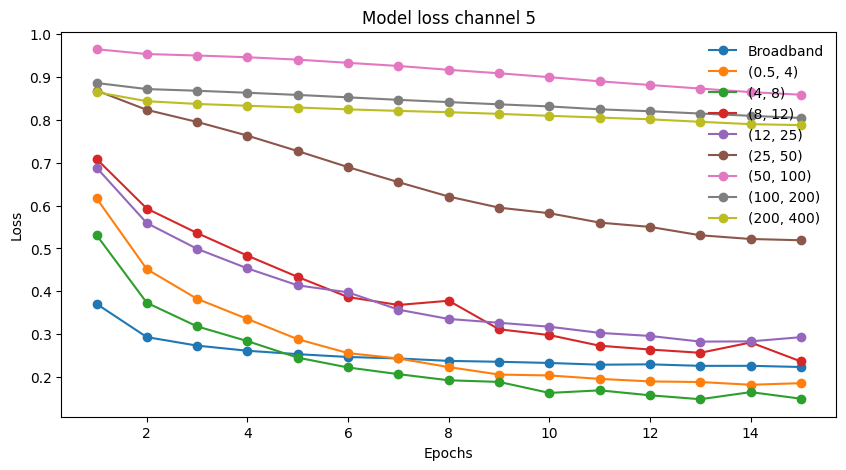

In [24]:
# plot the losses of ch15 for all bands
fig,ax = plt.subplots(1,1,figsize=(10,5))

ax.plot(list(range(1,16)) ,lossesAll[5,:,:],'o-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss channel 5')
# add legend without boxing
ax.legend(['Broadband'] + [str(bands[i]) for i in range(len(bands))], frameon=False, loc='upper right')

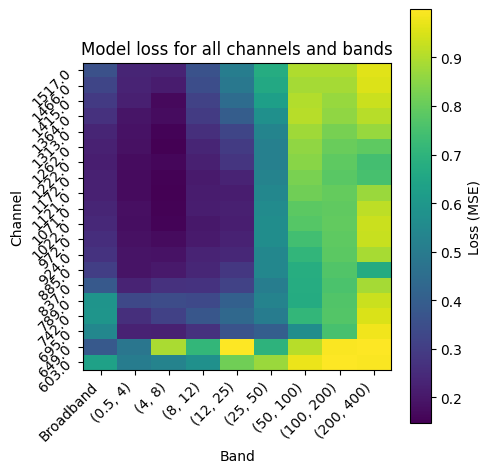

In [25]:
# plot a matrix of losses for the last epoch for all channels and bands
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square 
cax = ax.imshow(lossesAll[:,-1,:], aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model loss for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(visp_df.dorsal_ventral_ccf_coordinate, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('Loss (MSE)')
plt.tight_layout()


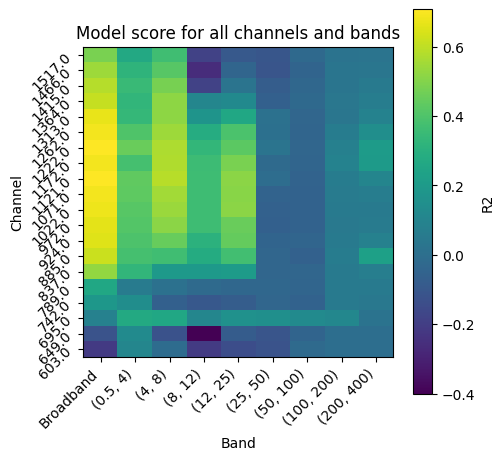

In [26]:
# compute model scores for all channels and bands for the training data and the test data
scoresTrain = np.zeros((num_channels, len(bands)+1))
scoresTest = np.zeros((num_channels, len(bands)+1))

for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        yHat_train = models[chani, bandi].evaluate(X_trainT)
        yHat_test  = models[chani, bandi].evaluate(X_testT)
        r2_train = r2_score(y_trainT[:,chani, bandi].cpu().detach().numpy(), yHat_train)
        r2_test  = r2_score(y_testT[:,chani, bandi].cpu().detach().numpy(), yHat_test)
        scoresTrain[chani, bandi] = r2_train
        scoresTest[chani, bandi] = r2_test
      
        
# plot as a matrix
fig,ax = plt.subplots(1,1,figsize=(5,5))
# make the plot square
cax = ax.imshow(scoresTest, aspect='equal', cmap='viridis')
ax.set_xlabel('Band')
ax.set_ylabel('Channel')
ax.set_title('Model score for all channels and bands')
ax.set_yticks(range(num_channels))
ax.set_yticklabels(visp_df.dorsal_ventral_ccf_coordinate, rotation=45)
ax.set_xticks(range(len(bands)+1))
ax.set_xticklabels(['Broadband'] + [str(bands[i]) for i in range(len(bands))], rotation=45, ha='right')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
cbar = fig.colorbar(cax)
cbar.set_label('R2')

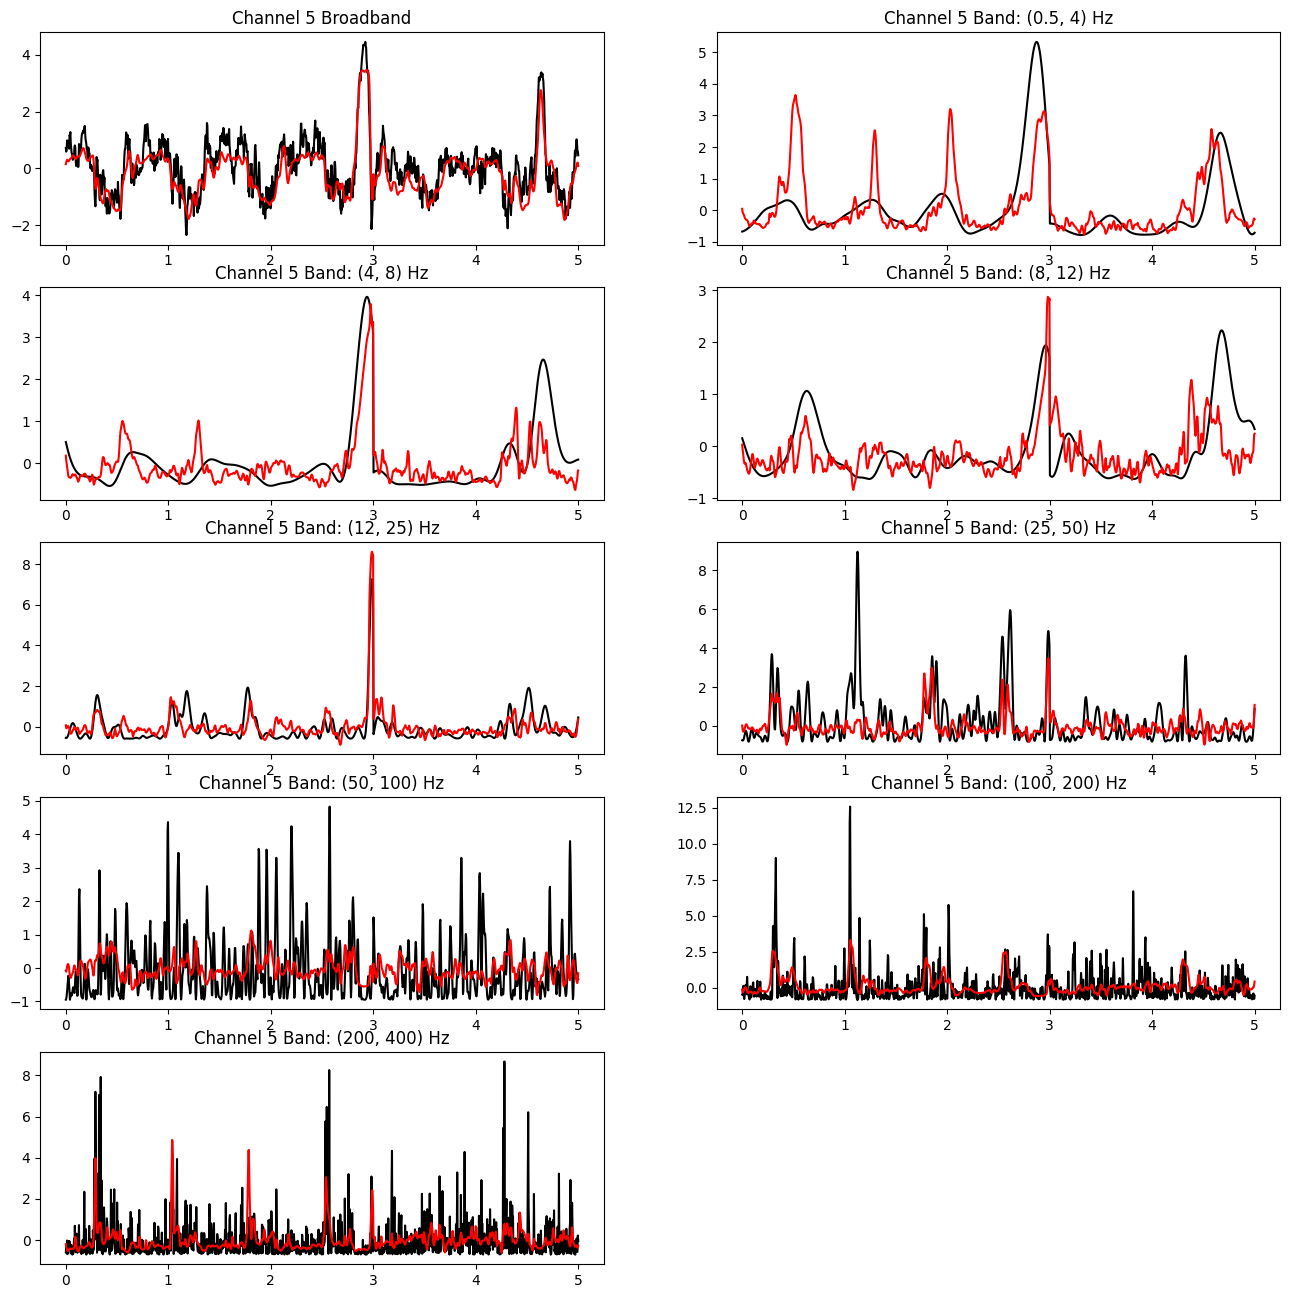

In [27]:
# plot the data and prediction for all bands from a single channel
chani = 5
fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2, figsize=(16, 16))

for bandi in range(len(bands)+1):
    yHat_test = models[chani, bandi].evaluate(X_testT)
    ax.flat[bandi].plot(np.linspace(0,5,int(5/bin_size)), y_testT.cpu().detach().numpy()[:int(5/bin_size),chani, bandi],'k',label='LFP')
    ax.flat[bandi].plot(np.linspace(0,5,int(5/bin_size)), yHat_test[:int(5/bin_size)],'r',label='LSTM')
    if bandi == 0:
        ax.flat[bandi].set_title('Channel ' + str(chani) + ' Broadband')
    else:
        ax.flat[bandi].set_title('Channel ' + str(chani) + ' Band: ' + str(bands[bandi-1]) + ' Hz')
    
fig.delaxes(ax.flat[-1])